<a href="https://colab.research.google.com/github/AbdelrahmanSallam04/Drowsy_Driver/blob/main/Drowsy_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define your base path
base_dir = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Function to count files in subfolders
def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only look at the final subdirectories
            print(f"Found {len(files)} files in: {root}")

count_files(base_dir)

Found 456 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/active
Found 453 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/fatigue
Found 5862 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/active
Found 3192 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/fatigue
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/active
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/fatigue


In [15]:
import tensorflow as tf

# Configuration
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard for models like MobileNetV2 or ResNet
BASE_PATH = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Create Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'train'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'val'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'test'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Show the class names to verify
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

Found 9054 files belonging to 2 classes.
Found 1824 files belonging to 2 classes.
Found 909 files belonging to 2 classes.
Detected classes: ['active', 'fatigue']


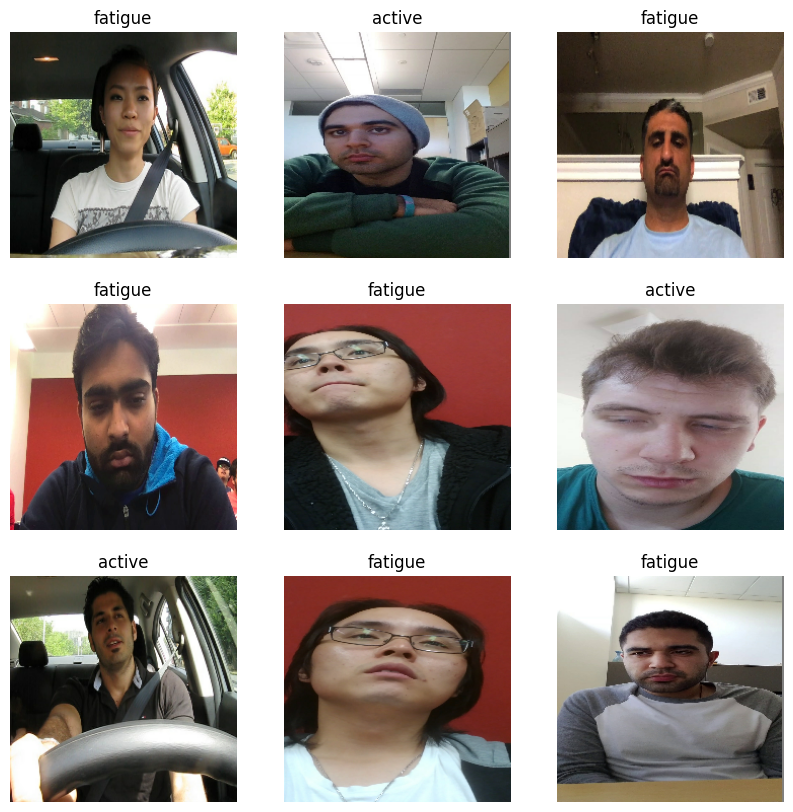

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [17]:
import tensorflow as tf
from tensorflow.keras import layers

# Replace your manual OpenCV function with this Layer
data_augmentation = tf.keras.Sequential([
    # Flip images to simulate different driver positions (LHD vs RHD)
    layers.RandomFlip("horizontal"),

    # Slight rotation (0.02 = ~7°) to account for head tilting
    layers.RandomRotation(0.02),

    # Adjust brightness (±30%) to simulate different times of day/night driving
    layers.RandomBrightness(0.3),

    # Adjust contrast to help the model find edges in low-light conditions
    layers.RandomContrast(0.3),

    # Shifting the image slightly to make the model robust to camera mounting positions
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
])

# --- APPLYING TO DATASET ---
# We use .map to inject the augmentation logic into the data pipeline.
# 'training=True' ensures augmentation only happens during training, not evaluation.
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# --- OPTIMIZATION ---
# AUTOTUNE allows the CPU to prepare the next batch of images (augmenting/loading)
# while the GPU is training on the current batch.
# This eliminates "bottlenecks" where the GPU is waiting for data.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

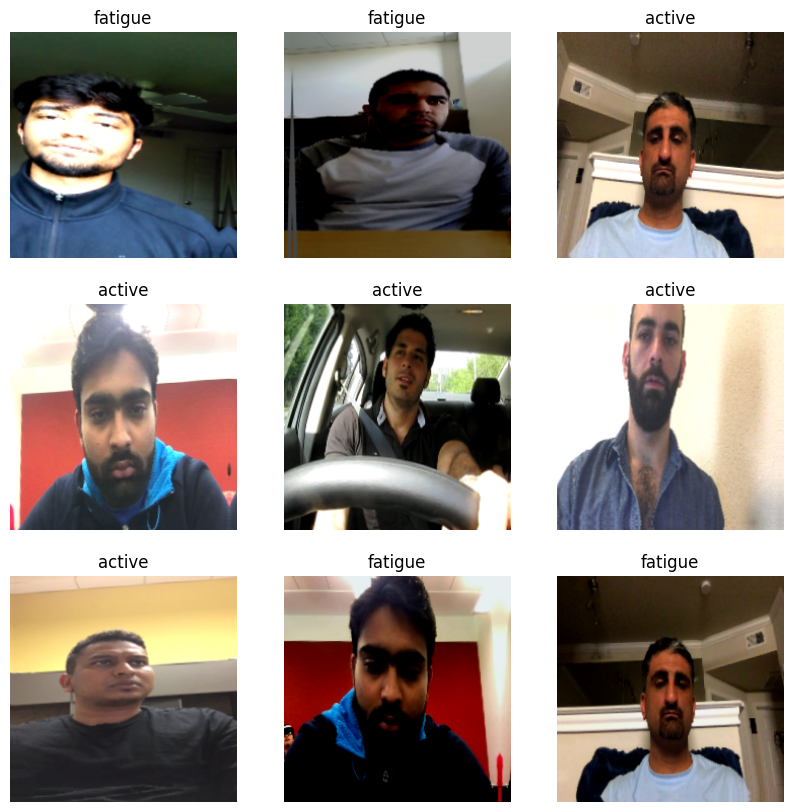

In [18]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")